In [ ]:
## Import required libraries
##%matplotlib inline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
## Read in the csv file as a dataframe called df 

In [3]:
df = pd.read_csv('911.csv')

In [ ]:
## Check the info() of the df

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [ ]:
## Check the head

In [7]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [13]:
zip_counts = df['zip'].value_counts()
zip_counts.head()

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

In [15]:
twp_counts = df['twp'].value_counts()
twp_counts.head()

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

In [17]:
titles = df['title'].nunique()
titles

110

## Creating new features/columns

In [ ]:
##In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. 
## .split() and .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.



In [21]:
df['Reason'] = df['title'].apply(lambda x: x.split(':')[0] if isinstance(x, str) else None)

print(df[['title', 'Reason']])

                             title   Reason
0           EMS: BACK PAINS/INJURY      EMS
1          EMS: DIABETIC EMERGENCY      EMS
2              Fire: GAS-ODOR/LEAK     Fire
3           EMS: CARDIAC EMERGENCY      EMS
4                   EMS: DIZZINESS      EMS
...                            ...      ...
99487  Traffic: VEHICLE ACCIDENT -  Traffic
99488  Traffic: VEHICLE ACCIDENT -  Traffic
99489             EMS: FALL VICTIM      EMS
99490         EMS: NAUSEA/VOMITING      EMS
99491  Traffic: VEHICLE ACCIDENT -  Traffic

[99492 rows x 2 columns]


In [ ]:
## finding the  most common Reason for a 911 call based off of this new column?

In [37]:
reason_counts = df['Reason'].value_counts()
reason_counts

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

In [ ]:
##using seaborn to create a countplot of 911 calls by Reason.


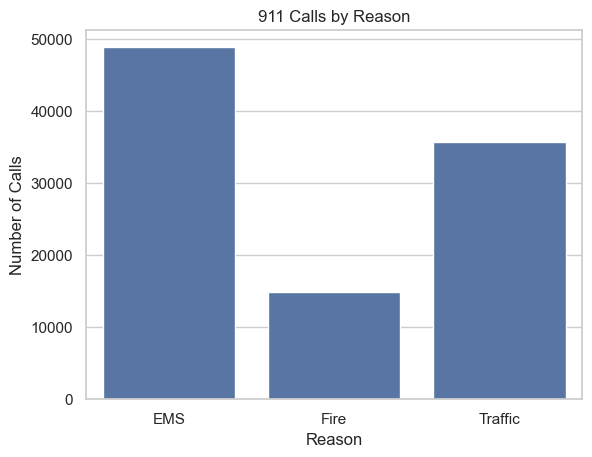

In [29]:
sns.set(style='whitegrid')
sns.countplot(x='Reason', data=df)
plt.title('911 Calls by Reason')
plt.xlabel('Reason')
plt.ylabel('Number of Calls')
plt.show()


In [49]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
 9   Reason     99492 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 7.6+ MB
None


In [57]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['timeStamp']

0       2015-12-10 17:40:00
1       2015-12-10 17:40:00
2       2015-12-10 17:40:00
3       2015-12-10 17:40:01
4       2015-12-10 17:40:01
                ...        
99487   2016-08-24 11:06:00
99488   2016-08-24 11:07:02
99489   2016-08-24 11:12:00
99490   2016-08-24 11:17:01
99491   2016-08-24 11:17:02
Name: timeStamp, Length: 99492, dtype: datetime64[ns]

In [65]:
df['Hour'] = df['timeStamp'].dt.hour

df['Month'] = df['timeStamp'].dt.month

df['day_name'] = df['timeStamp'].dt.day_name()

df[['timeStamp', 'Hour', 'Month', 'day_name']]


,timeStamp,Hour,Month,day_name
0,2015-12-10 17:40:00,17,12,Thursday
1,2015-12-10 17:40:00,17,12,Thursday
2,2015-12-10 17:40:00,17,12,Thursday
3,2015-12-10 17:40:01,17,12,Thursday
4,2015-12-10 17:40:01,17,12,Thursday
...,...,...,...,...
99487,2016-08-24 11:06:00,11,8,Wednesday
99488,2016-08-24 11:07:02,11,8,Wednesday
99489,2016-08-24 11:12:00,11,8,Wednesday
99490,2016-08-24 11:17:01,11,8,Wednesday


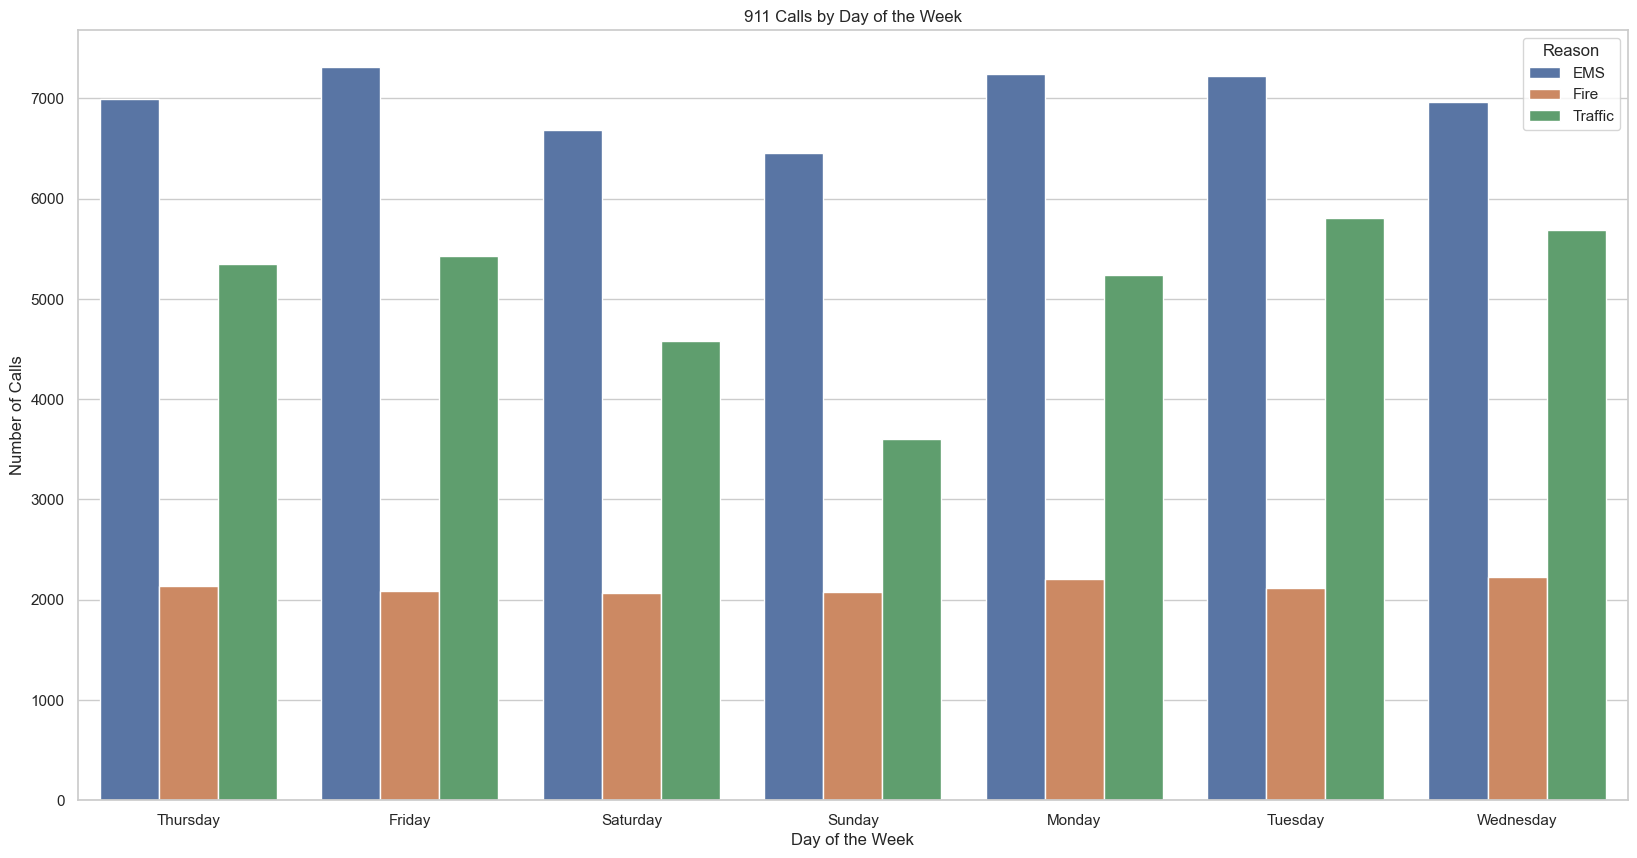

In [75]:
sns.set(style='whitegrid')
plt.figure(figsize=(20, 10)) 
sns.countplot(x='day_name', data=df, hue='Reason')
plt.title('911 Calls by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Calls')
plt.show()


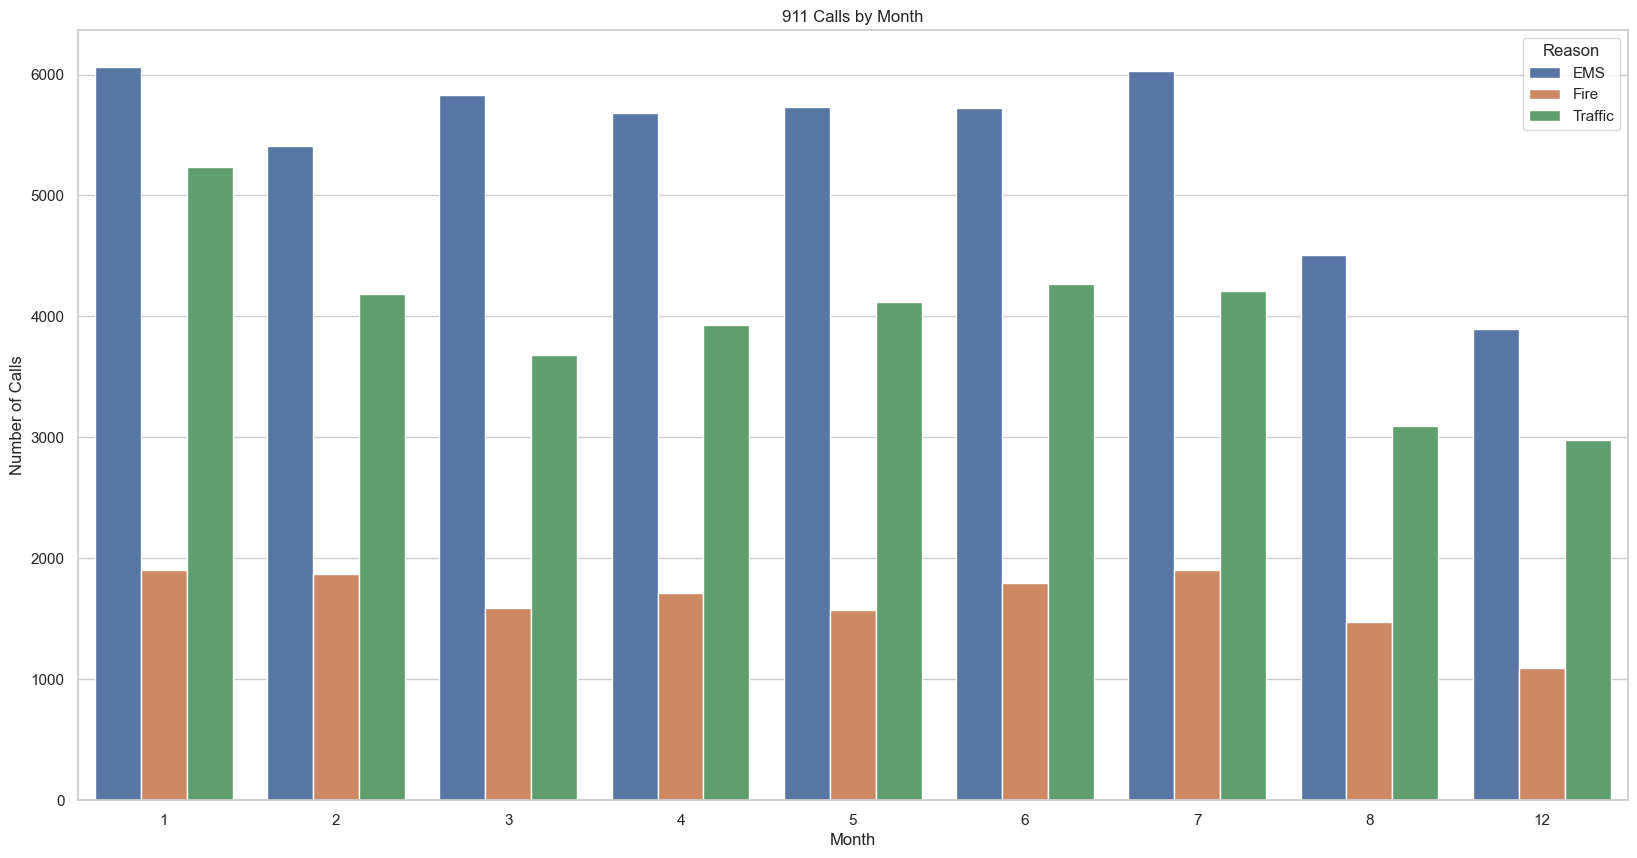

In [77]:
sns.set(style='whitegrid')
plt.figure(figsize=(20, 10))  
sns.countplot(x='Month', data=df, hue='Reason')
plt.title('911 Calls by Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.show()


In [ ]:
## about the month plot 

In [ ]:
We could observe that the month 9,10,11 are missing.
The reason Fire has the least number of calls out of all three whereas, the EMS is the most. 
The month 1 has the most amount of calls received. 

In [79]:
byMonth = df.groupby('Month').count()
byMonth

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,day_name
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423
6,11786,11786,11786,10212,11786,11786,11777,11732,11786,11786,11786,11786
7,12137,12137,12137,10633,12137,12137,12133,12088,12137,12137,12137,12137
8,9078,9078,9078,7832,9078,9078,9073,9025,9078,9078,9078,9078
12,7969,7969,7969,6907,7969,7969,7963,7916,7969,7969,7969,7969


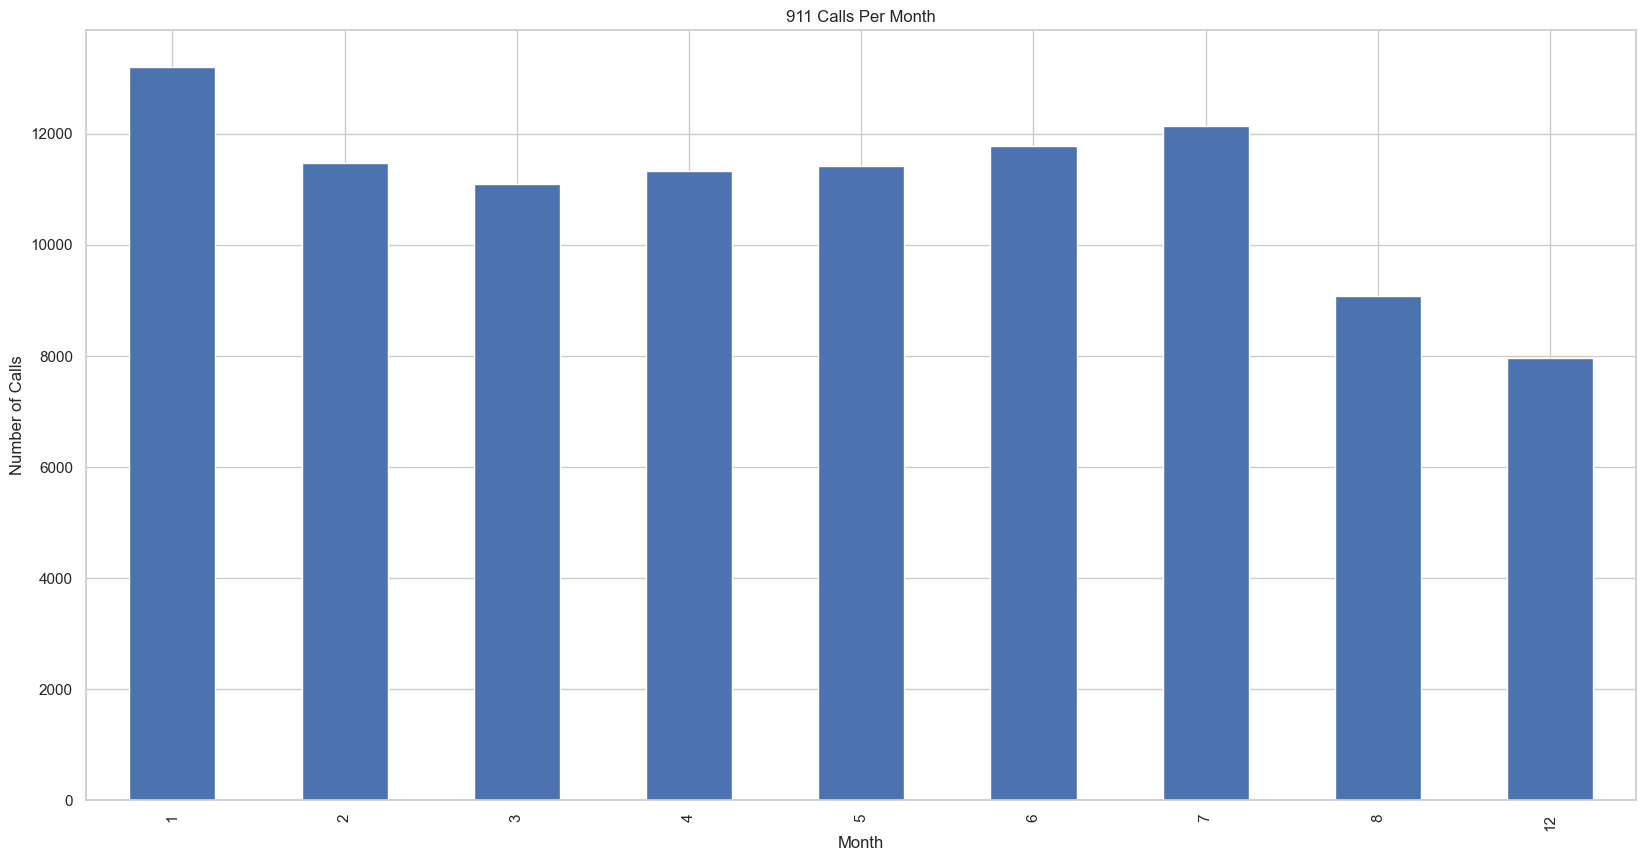

In [83]:
plt.figure(figsize=(20, 10))  
byMonth['timeStamp'].plot(kind='bar')
plt.title('911 Calls Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.show()


In [85]:
df['Date'] = df['timeStamp'].dt.date

print(df[['timeStamp', 'Date']].head())


            timeStamp        Date
0 2015-12-10 17:40:00  2015-12-10
1 2015-12-10 17:40:00  2015-12-10
2 2015-12-10 17:40:00  2015-12-10
3 2015-12-10 17:40:01  2015-12-10
4 2015-12-10 17:40:01  2015-12-10


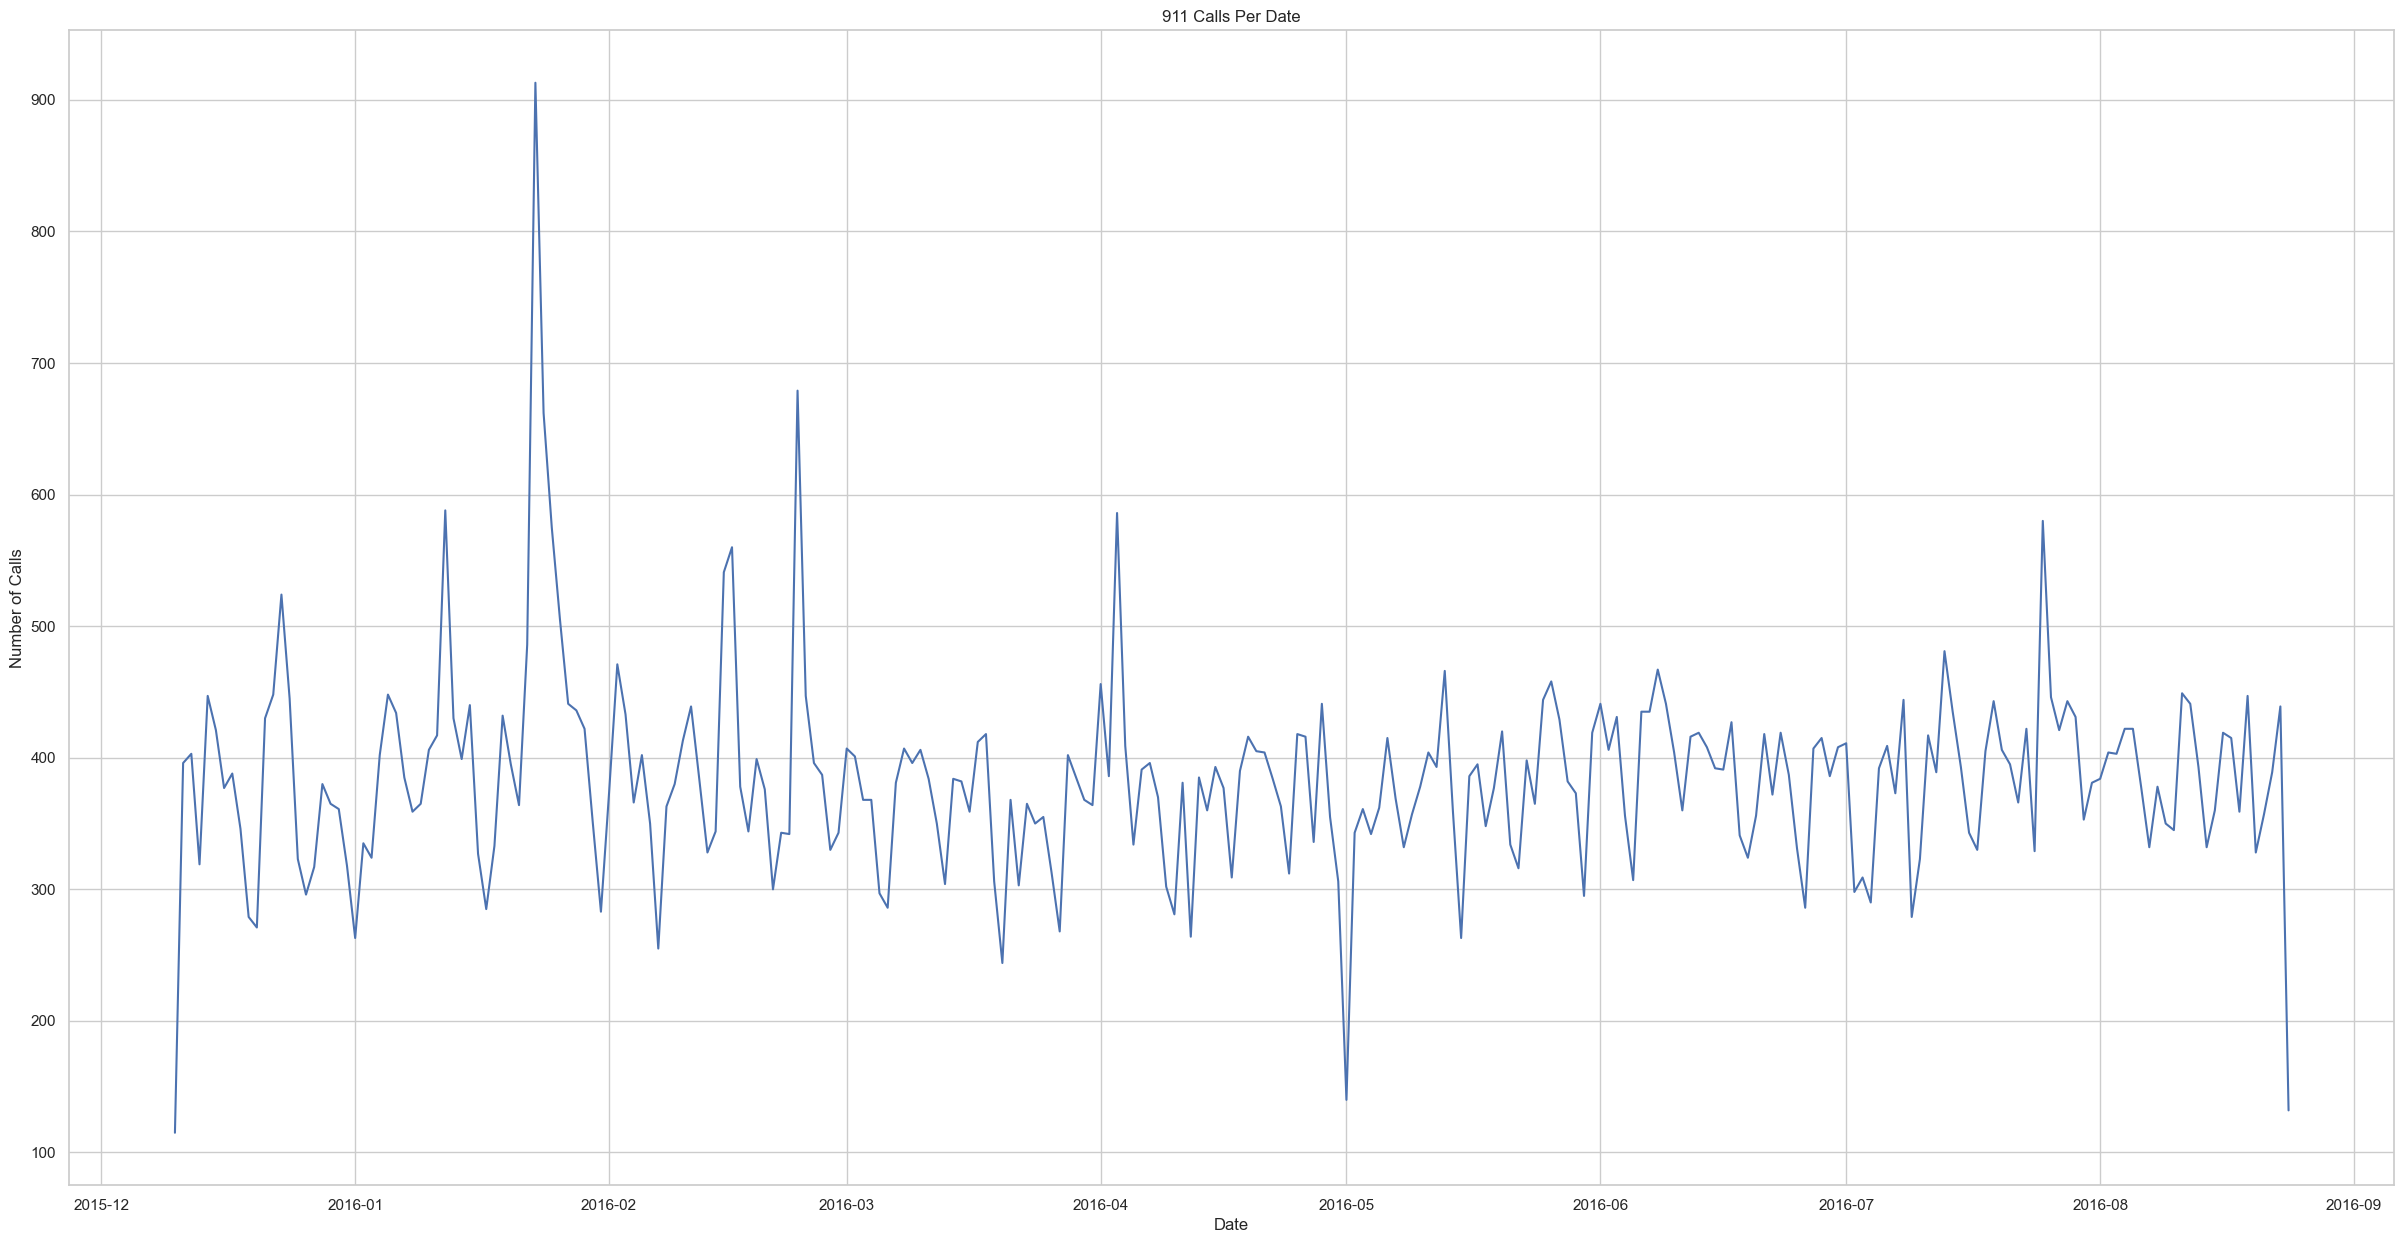

In [173]:
byDate = df.groupby('Date').count()
plt.figure(figsize=(30, 15)) 
byDate['timeStamp'].plot(kind='line')
plt.title('911 Calls Per Date')
plt.xlabel('Date')
plt.ylabel('Number of Calls')
plt.show()

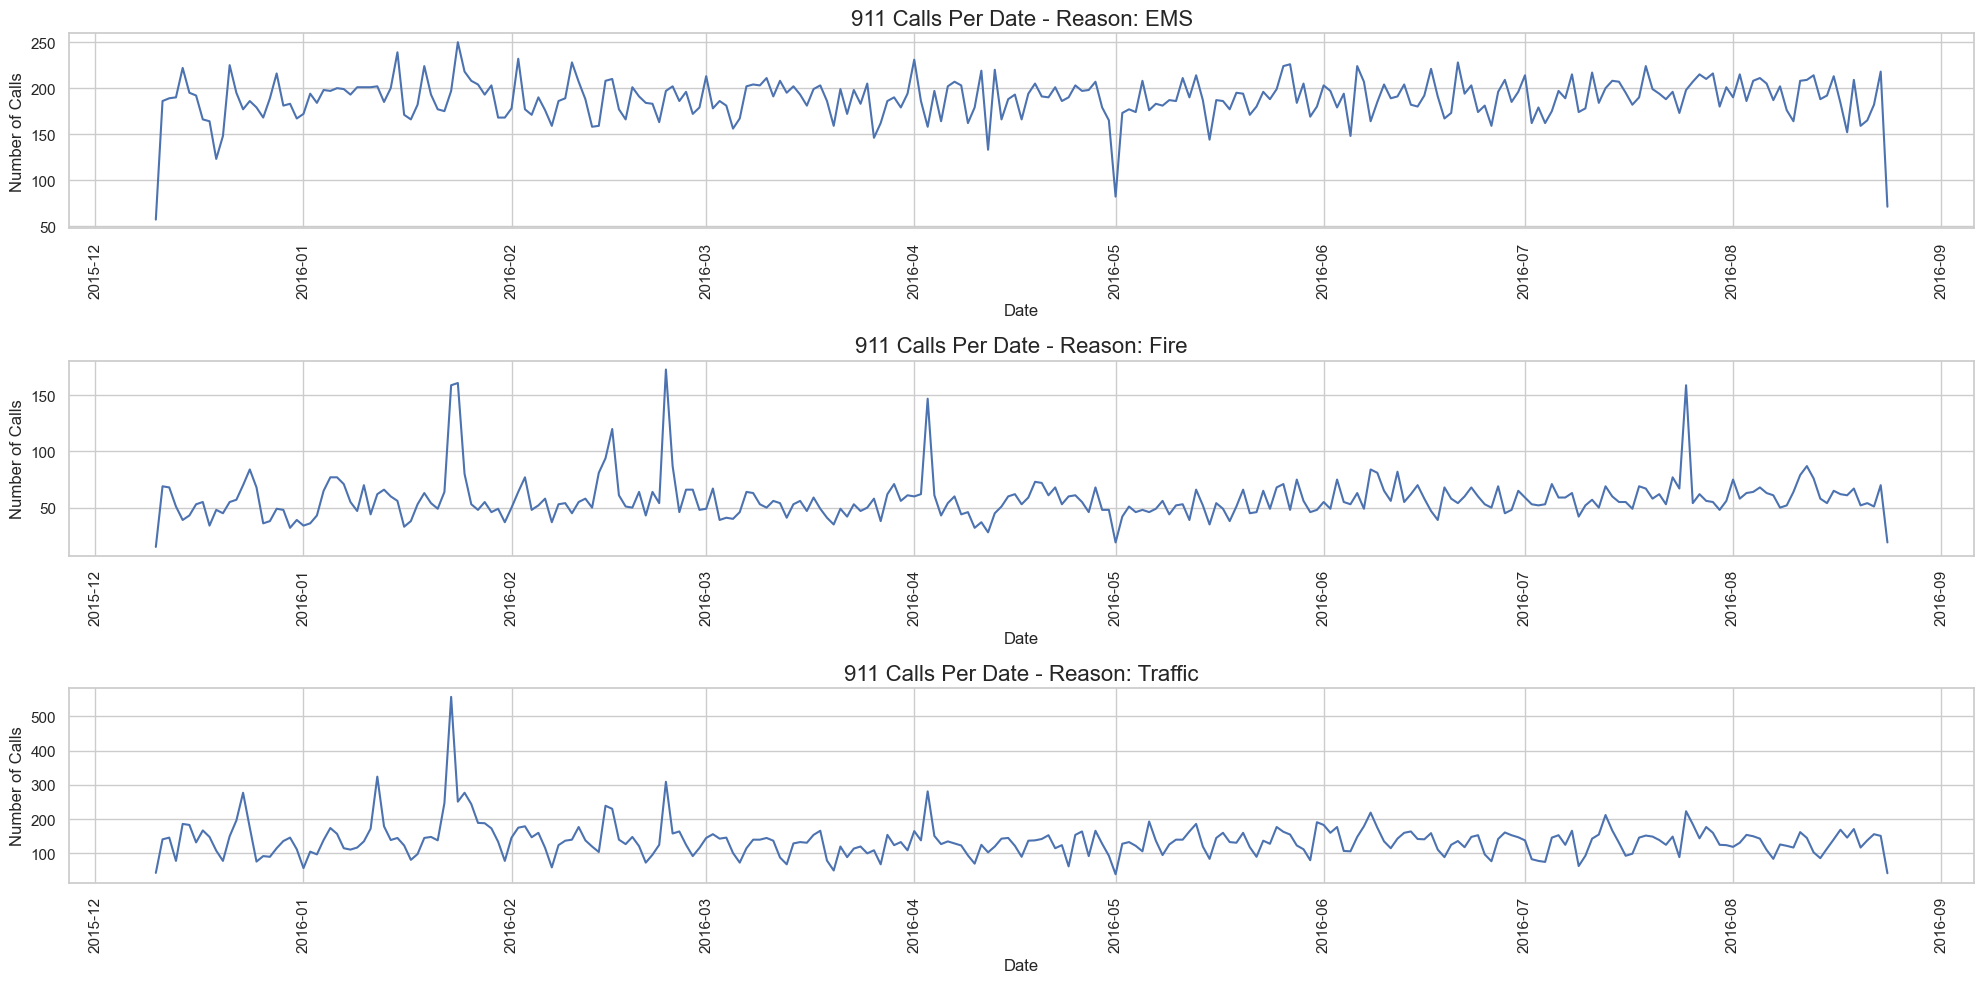

In [177]:
plt.figure(figsize=(20, 10))
reasons = ['EMS', 'Fire', 'Traffic']
for i, reason in enumerate(reasons, 1):
    reason_df = df[df['Reason'] == reason]
    
    byDate_reason = reason_df.groupby('Date').count()
    
    plt.subplot(3, 1, i)  
    
    byDate_reason['timeStamp'].plot(kind='line')
    
    plt.title(f'911 Calls Per Date - Reason: {reason}', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Calls', fontsize=12)
    plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


In [ ]:
We could see the spike in call for fire and traffic reason around the end of the month 1 due to the weather being chilly and cold as its end of janauary. 
The reason EMS is thorough throughout the year, but has a drop in month 5.
Traffic slows down a lot during the winter season as shown.
Fire spikes again at winter cause of the humidity and the air being cool. 
Fire also has a spike at the month 3 and 4 as well.

In [147]:
dayHour =  df.groupby(by=['Hour', 'day_name', 'Reason']).count().unstack()
dayHour.head()


lat               lng              desc               zip  ...  \
Reason         EMS Fire Traffic  EMS Fire Traffic  EMS Fire Traffic  EMS  ...   
Hour day_name                                                             ...   
0    Friday    159   45      71  159   45      71  159   45      71  145  ...   
     Monday    178   39      65  178   39      65  178   39      65  166  ...   
     Saturday  215   56     104  215   56     104  215   56     104  196  ...   
     Sunday    219   61     103  219   61     103  219   61     103  202  ...   
     Thursday  158   43      77  158   43      77  158   43      77  145  ...   

                 addr    e              Month              Date               
Reason        Traffic  EMS Fire Traffic   EMS Fire Traffic  EMS Fire Traffic  
Hour day_name                                                                 
0    Friday        71  159   45      71   159   45      71  159   45      71  
     Monday        65  178   39      65   178   39      65  178   39      65  
     Saturday     100  215   56     104   215   56     104  215   56     104  
     Sunday       101  219   61     103   219   61     103  219   61     103  
     Thursday      77  158   43      77   158   43      77  158   43      77  

[5 rows x 33 columns]

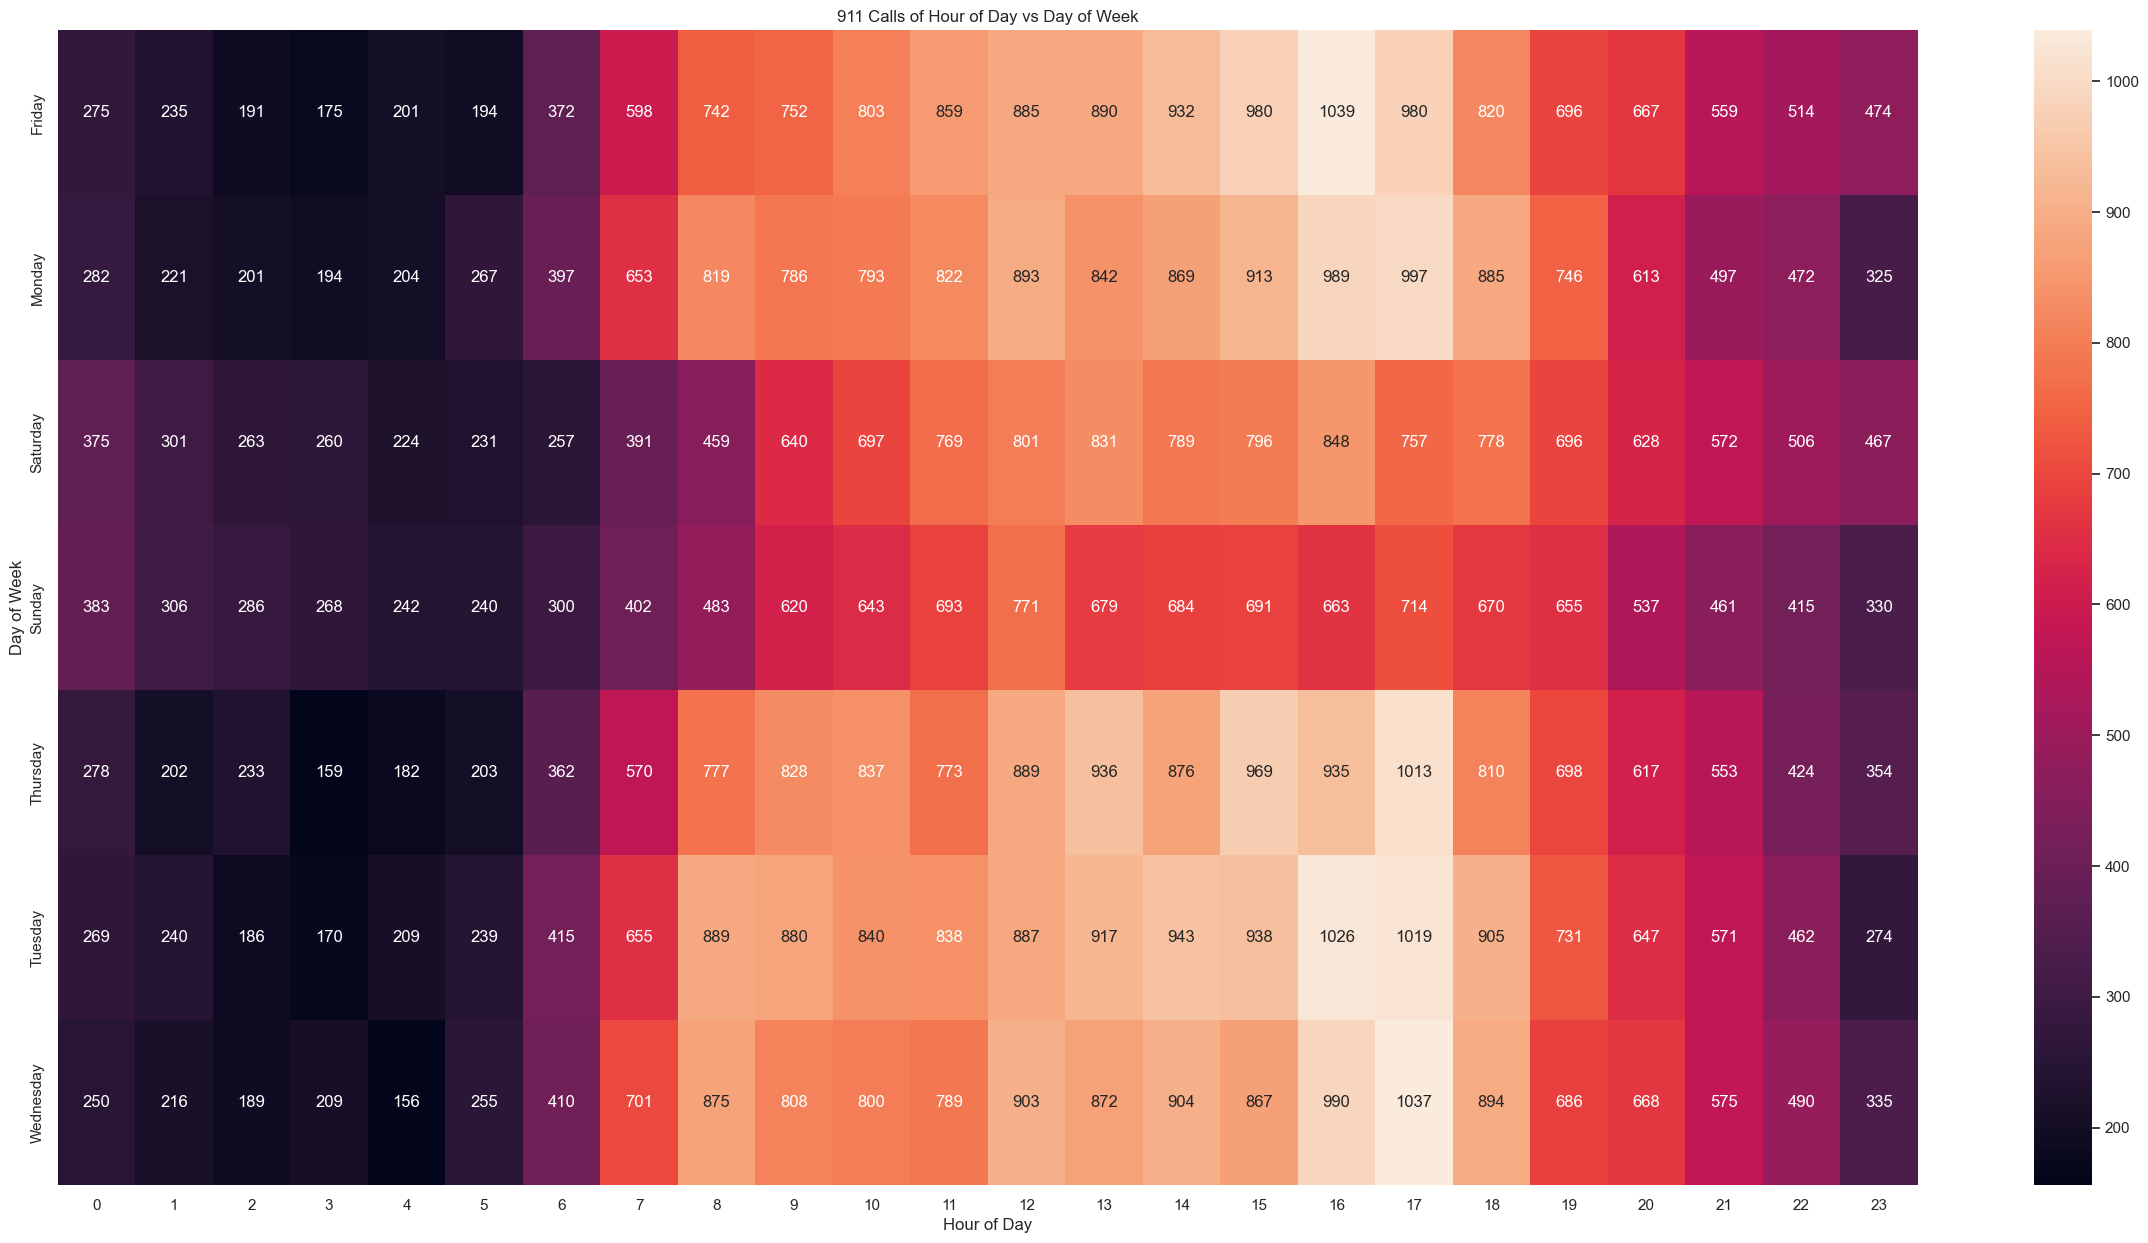

In [181]:
heatmap_data = grouped.pivot_table(index='day_name', columns='Hour', values='Count', aggfunc='sum')
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(30, 15))  
sns.heatmap(heatmap_data, annot=True, fmt='d')

plt.title('911 Calls of Hour of Day vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.show()

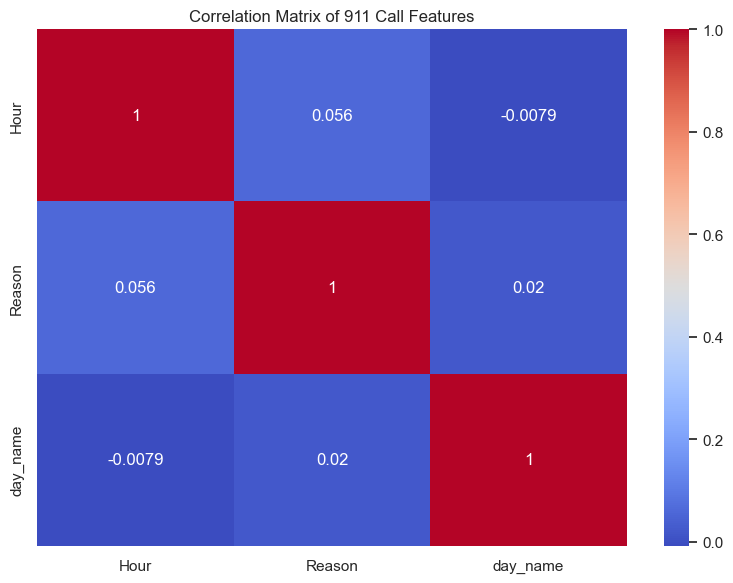

In [309]:
df_corr = df.copy()
df_corr['Reason'] = df_corr['Reason'].astype('category').cat.codes
df_corr['day_name'] = df_corr['day_name'].astype('category').cat.codes

cols_to_corr = ['Hour', 'Reason', 'day_name']
corr_matrix = df_corr[cols_to_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of 911 Call Features')
plt.tight_layout()
plt.show()


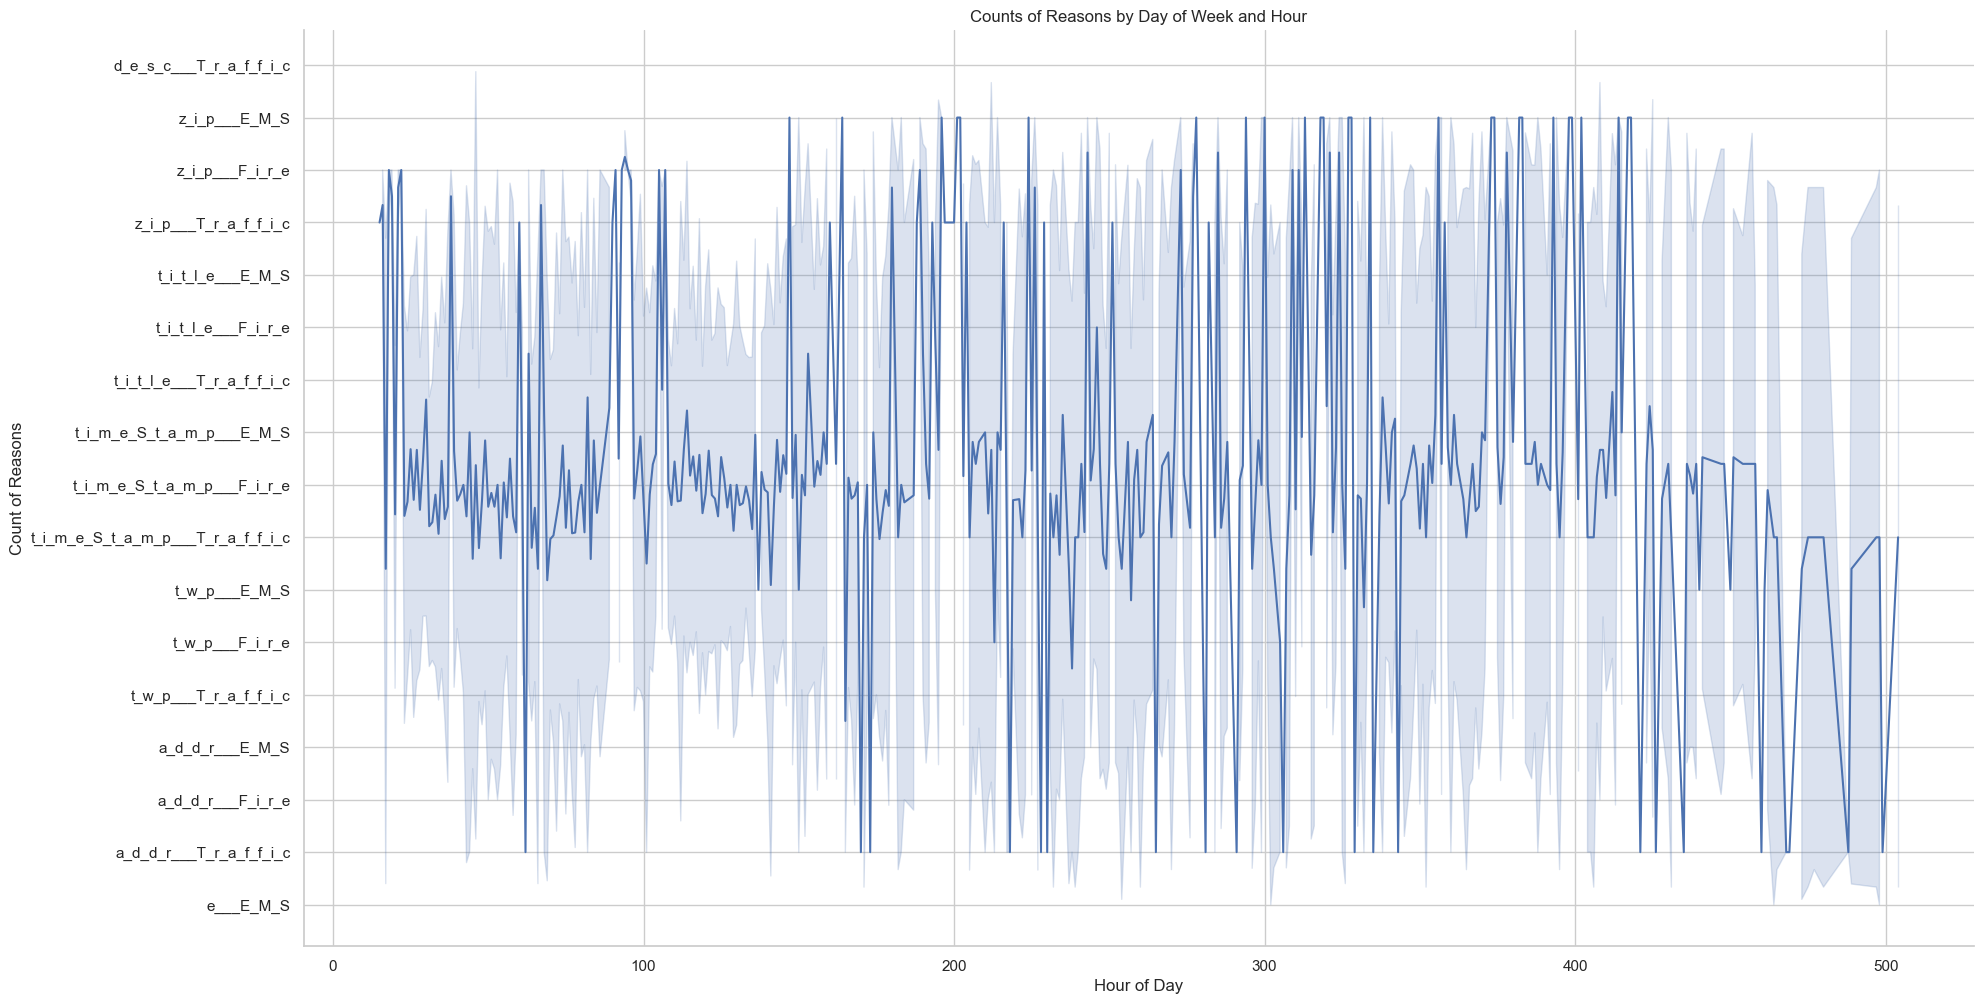

In [336]:
## Reshape dayHour into a long format
dayHour_long = dayHour.reset_index().melt(id_vars=['day_name'], value_vars=dayHour.columns, 
                                          var_name='Hour', value_name='Count')

# Create a relplot
sns.relplot(data=dayHour_long, x='Count', y='Hour', kind='line', height=10, aspect=2)

plt.title('Counts of Reasons by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Reasons')
plt.show()


In [ ]:
The calls start of slow at the morning around 3 - 7 am and it spiked at around 15-17 hr of the day. All the days are like that other than some days which are slows as in the graph above. 

In [ ]:
##Can we perform predictions on this dataset using linear regression? 

Yes, we can perform linear regression on this data as the independent variable could be attributes such as:

Hour of the day
Day of the week(this can be encoded numerically)
Month (numerical or dummy encoded)
Reason for the call (categorical)

Then,we would model the linear regression by splitting the data and finding the r2 mean square. If the value is negative then the model is not worth evaluating, if its near to 1 or 1
then its a perfect model, and if its near to 0 then it can be considerable. 

Limitations: 
Linear regression assumes a linear relationship between the independent variables and the target variable. 
Linear regression assumes that the variance of errors is constant across all levels.
If you include too many features, especially if some of them are irrelevant, you risk overfitting your model. 